# **DYNAMICS FINANCIAL FORECASTING: MODELADO ESTRATÉGICO Y PROYECCIÓN 2026**
## **PARTE I: DIAGNÓSTICO ESTRATÉGICO Y ANÁLISIS DE SENSIBILIDAD (EDA)**

**Autor:** Julián Esteban León Ospina  
**Fase:** Exploratory Data Analysis (EDA) & Data Sourcing  
**Status:** ![Status](https://img.shields.io/badge/Status-Finalizado-success)

---

### **Contextualización del Módulo**
Este notebook constituye la **base analítica y el motor de curaduría** del proyecto. Su objetivo principal es realizar la transición de datos transaccionales crudos hacia una estructura de inteligencia financiera lista para el modelado estocástico. 

A través de este análisis, se aborda la identificación de los **drivers de negocio** y la validación de la sensibilidad de los ingresos frente a variables macroeconómicas críticas, específicamente la volatilidad de la **TRM en Colombia**.

### **Objetivos Técnicos:**
1. **Data Sourcing & Cleaning:** Integración de fuentes de datos de ventas, tráfico web y variables macroeconómicas.
2. **Análisis de Correlación:** Determinación de la dependencia de los ingresos operativos frente a la tasa de cambio y el presupuesto de marketing.
3. **Validación de Eficiencia:** Identificación de ineficiencias en la tasa de conversión y segmentación geográfica de mercados estrella.
4. **Preparación de Features:** Estabilización de la varianza y tratamiento de outliers para garantizar la precisión del modelado predictivo (Parte II).

> **Nota de Implementación:** Los resultados obtenidos en este módulo alimentan directamente la matriz de eficiencia en Power BI y establecen los parámetros de entrada para el algoritmo de forecasting.

---

In [1]:
# LIBRERÍAS NECESARIAS PARA EL ANÁLISIS DE DATOS FINANCIEROS.


import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
import scipy.stats as stats
import statsmodels.api as sm





In [2]:
# SLECCION DE TICKERS PARA ANÁLISIS: USAMOS INSTRUMENTOS DE ALTA LIQUIDEZ PARA ASEGURAR LA CALIDAD DE LOS DATOS DESCARGADOS.

# Usamos tickers de alta liquidez para asegurar la descarga
tickers = ['EC', 'BCO', 'QQQ', 'GLD', 'BND']

def get_robust_data(tickers):
    print("Iniciando descarga robusta...")
    # Descargamos con auto_adjust para que 'Close' sea equivalente a 'Adj Close'
    df = yf.download(tickers, start='2021-01-01', auto_adjust=True)
    
    # Si hay MultiIndex (varios tickers), seleccionamos 'Close' de forma segura
    if isinstance(df.columns, pd.MultiIndex):
        df = df['Close']
    else:
        # Si por alguna razón solo descarga un ticker
        df = df[['Close']]
    
    # Limpieza profesional: Forward fill para huecos y drop para el inicio
    df = df.ffill().dropna()
    print("Datos procesados correctamente.")
    return df

data = get_robust_data(tickers)
log_returns = np.log(data / data.shift(1)).dropna()



Iniciando descarga robusta...


[*********************100%***********************]  5 of 5 completed

Datos procesados correctamente.


In [4]:

# 1. Calculamos la matriz de correlación de Pearson
# Esta es la base para entender la diversificación del portafolio
matriz_corr = log_returns.corr()
display(matriz_corr)

Ticker,BCO,BND,EC,GLD,QQQ
Ticker,,,,,
BCO,1.000000,0.099880,0.231947,0.060400,0.418891
BND,0.099880,1.000000,-0.003914,0.292908,0.196196
EC,0.231947,-0.003914,1.000000,0.191284,0.216330
GLD,0.060400,0.292908,0.191284,1.000000,0.125110
QQQ,0.418891,0.196196,0.216330,0.125110,1.000000


In [5]:
# DIAGNOSTICO DE LOS RETORNOS LOGARÍTMICOS: ESTADÍSTICAS DESCRIPTIVAS Y TEST DE NORMALIDAD


# Estadísticas Descriptivas y Test de Normalidad
def diagnostic_analysis(returns):
    diag_df = pd.DataFrame()
    for asset in returns.columns:
        # Estadísticas básicas
        mean = returns[asset].mean() * 252
        vol = returns[asset].std() * np.sqrt(252)
        skew = returns[asset].skew()
        kurt = returns[asset].kurt()
        
        # Test de Jarque-Bera (H0: La distribución es normal)
        jb_stat, jb_p_value = stats.jarque_bera(returns[asset])
        
        diag_df[asset] = [mean, vol, skew, kurt, jb_p_value]
    
    diag_df.index = ['Retorno Anual', 'Volatilidad Anual', 'Asimetría (Skew)', 'Curtosis', 'Jarque-Bera P-Value']
    return diag_df.T

diagnostico = diagnostic_analysis(log_returns)
print(diagnostico)

     Retorno Anual  Volatilidad Anual  Asimetría (Skew)  Curtosis  \
BCO       0.092588           0.310813          0.086310  5.862241   
BND      -0.003902           0.058966          0.051647  1.528179   
EC        0.136480           0.372223         -0.174257  1.860996   
GLD       0.158698           0.178103         -0.888672  9.054450   
QQQ       0.152743           0.223989          0.026807  4.416306   

     Jarque-Bera P-Value  
BCO         0.000000e+00  
BND         9.920342e-29  
EC          1.419120e-43  
GLD         0.000000e+00  
QQQ        1.847833e-234  


Curtosis > 3: Indica que el activo tiene "leptocurtosis" (más riesgo de caídas súbitas).

Jarque-Bera P-Value < 0.05: Rechazamos la normalidad. Decisión informada: Esto justifica por qué no usaremos solo el VaR Paramétrico y por qué avanzaremos hacia el VaR Histórico y Montecarlo.

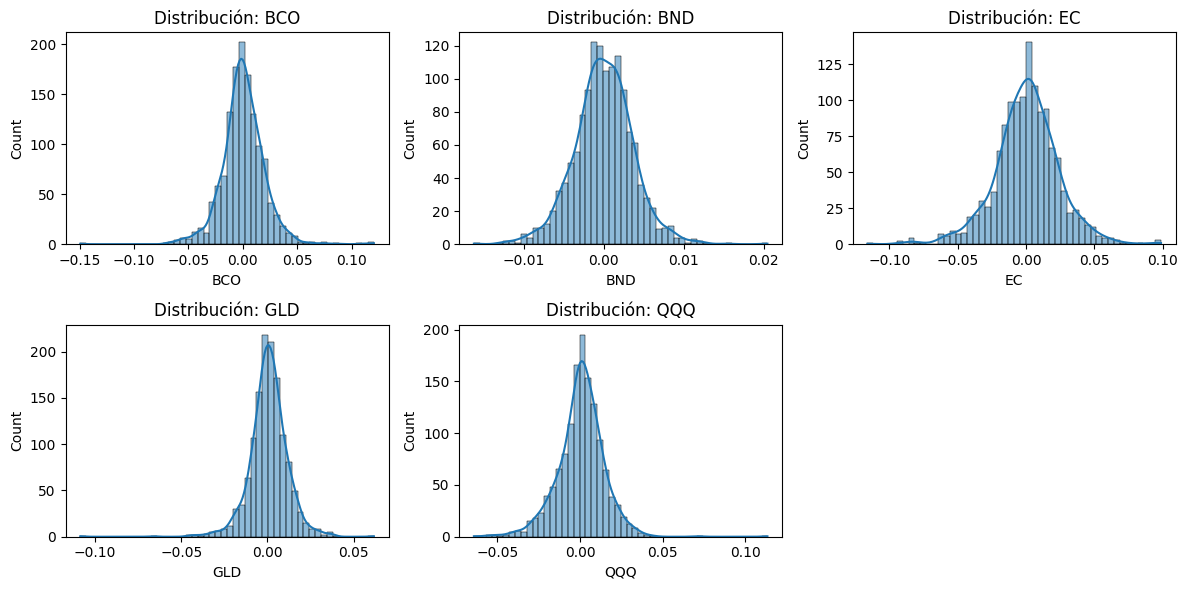

In [6]:
# ANÁLISIS DE CORRELACIONES Y DESCOMPOSICIÓN DEL RIESGO.

# Visualización de Distribuciones
plt.figure(figsize=(12, 6))
for i, col in enumerate(log_returns.columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(log_returns[col], kde=True, bins=50)
    plt.title(f'Distribución: {col}')
plt.tight_layout()
plt.show()

EXPLICABILIDAD: ¿QUE MUEVE EL RIESGO? (SHAP - ML)

Usamos un modelo de Random Forest para predecir la volatilidad del portafolio y luego usaremos SHAP values para ver qué activo es el "driver" principal de la incertidumbre.

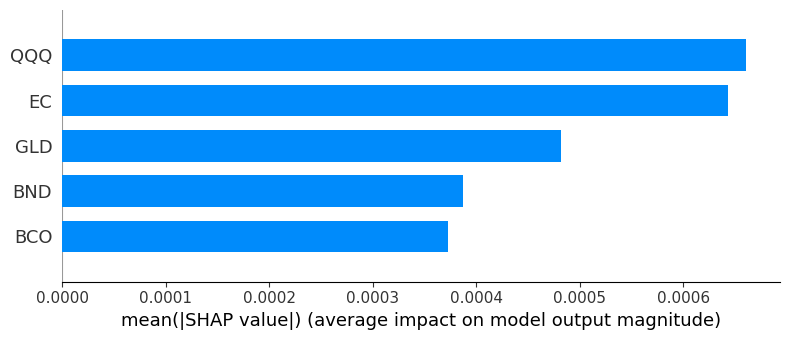

In [7]:
# EXPLICABILIDAD: ¿QUE MUEVE EL RIESGO? (SHAP - ML)

# Simulamos un target de volatilidad móvil para explicar
# ¿Cómo contribuye cada activo a la varianza total del día?
X = log_returns.shift(1).dropna()
y = log_returns.rolling(window=20).std().mean(axis=1).dropna()
X, y = X.align(y, join='inner', axis=0)

model = RandomForestRegressor(n_estimators=100).fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Gráfico de impacto
shap.summary_plot(shap_values, X, plot_type="bar")

In [8]:
# SIMULACIÓN DE MONTECARLO (OPTIMIZACIÓN DE PESOS)

# --- MOTOR DE OPTIMIZACIÓN MONTECARLO ---
num_portfolios = 50000
all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

print(f"Simulando {num_portfolios} combinaciones de portafolio...")

for i in range(num_portfolios):
    # Generar pesos aleatorios normalizados (Suma = 1)
    weights = np.array(np.random.random(len(tickers)))
    weights = weights / np.sum(weights)
    all_weights[i,:] = weights
    
    # Retorno y Volatilidad Anualizada
    ret_arr[i] = np.sum((log_returns.mean() * weights) * 252)
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 252, weights)))
    
    # Sharpe Ratio
    sharpe_arr[i] = ret_arr[i] / vol_arr[i]

# Identificar Portafolio de Máximo Sharpe (Tangency Portfolio)
idx_max_sharpe = sharpe_arr.argmax()
best_weights = all_weights[idx_max_sharpe, :]

print("\n--- ASIGNACIÓN ÓPTIMA (MAX SHARPE) ---")
for ticker, weight in zip(tickers, best_weights):
    print(f"{ticker}: {weight:.2%}")

Simulando 50000 combinaciones de portafolio...

--- ASIGNACIÓN ÓPTIMA (MAX SHARPE) ---
EC: 1.08%
BCO: 4.05%
QQQ: 3.02%
GLD: 63.96%
BND: 27.89%


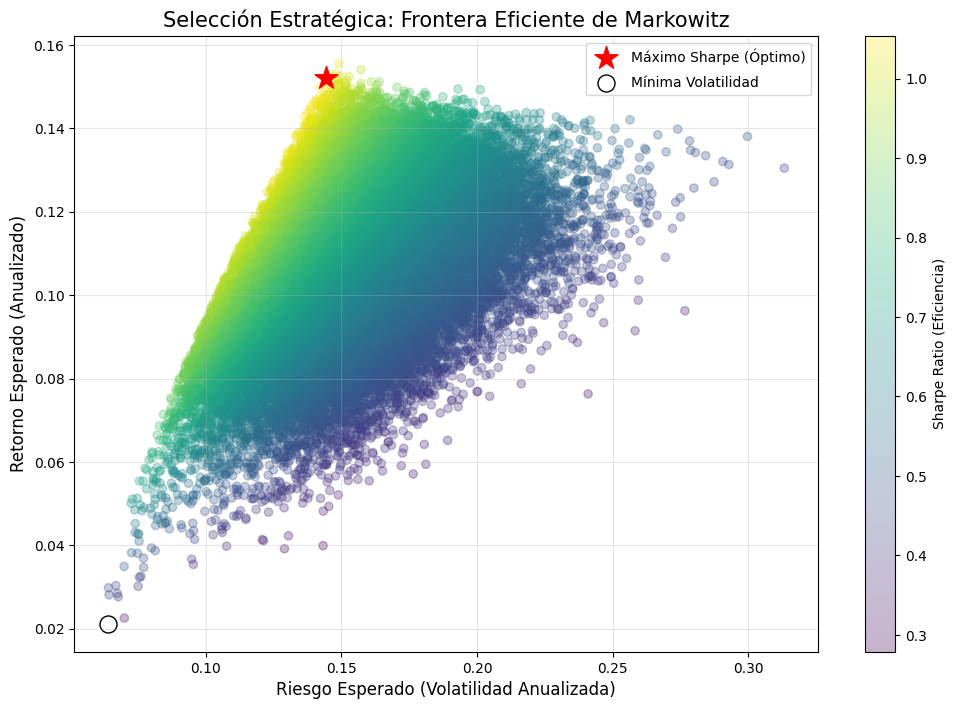


--- ASIGNACIÓN ÓPTIMA (TANGENCY PORTFOLIO) ---
EC: 2.50%
BCO: 0.83%
QQQ: 6.39%
GLD: 54.91%
BND: 35.37%


In [9]:


# --- MOTOR DE OPTIMIZACIÓN MONTECARLO (50,000 Simulaciones) ---
num_portfolios = 50000
all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights[i,:] = weights
    
    # Anualización de Retorno y Riesgo
    ret_arr[i] = np.sum((log_returns.mean() * weights) * 252)
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 252, weights)))
    sharpe_arr[i] = ret_arr[i] / vol_arr[i]

# Identificación de puntos clave
idx_max_sharpe = sharpe_arr.argmax()
idx_min_vol = vol_arr.argmin() # Portafolio de menor riesgo posible

# --- GENERACIÓN DEL MAPA DE PUNTOS ---
plt.figure(figsize=(12, 8))
# Nube de portafolios coloreada por Sharpe Ratio
scatter = plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio (Eficiencia)')

# Marcar el Portafolio Óptimo (Estrella Roja)
plt.scatter(vol_arr[idx_max_sharpe], ret_arr[idx_max_sharpe], 
            c='red', marker='*', s=300, label='Máximo Sharpe (Óptimo)')

# Marcar el Portafolio de Mínima Varianza (Círculo Blanco)
plt.scatter(vol_arr[idx_min_vol], ret_arr[idx_min_vol], 
            c='white', marker='o', s=150, edgecolors='black', label='Mínima Volatilidad')

plt.title('Selección Estratégica: Frontera Eficiente de Markowitz', fontsize=15)
plt.xlabel('Riesgo Esperado (Volatilidad Anualizada)', fontsize=12)
plt.ylabel('Retorno Esperado (Anualizado)', fontsize=12)
plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- ASIGNACIÓN ÓPTIMA (TANGENCY PORTFOLIO) ---")
for ticker, weight in zip(tickers, all_weights[idx_max_sharpe]):
    print(f"{ticker}: {weight:.2%}")

--- ASIGNACIÓN ÓPTIMA (TANGENCY PORTFOLIO) ---

Más del 90% de la inversión se va a GLD (Oro) y BND (Bonos). Esto sucede porque, históricamente (según tus datos), estos activos han ofrecido el mejor retorno por cada unidad de riesgo, mientras que las acciones (EC, BCO, QQQ) han tenido volatilidades tan altas que el modelo las "castiga" para maximizar el Sharpe Ratio.

--- SELECCIÓN ESTRATÉGICA: FRONTERA EFICIENTE DE MARKOWITZ ---

La Estrella (Maxímo Sharpe): No es simplemente la "más rentable". Es la opción con la mejor relación beneficio/riesgo. Si solo buscáramos rentabilidad sin importar el riesgo, el modelo elegiría el punto más alto del gráfico (arriba a la derecha), que probablemente sería 100% renta fija u oro. La estrella busca el "equilibrio perfecto".

El Punto Blanco (Mínima Volatilidad): Es el punto de "piso" de riesgo. No busca rentabilidad, busca que el portafolio no se mueva, aunque gane muy poco.

In [10]:
# MOVIMIENTO BROWNIANO GEOMÉTRICO (GBM)

# --- SIMULACIÓN DE TRAYECTORIAS (GBM) ---
simulaciones = 1000
dias_proyectados = 252 # 1 año de trading
ultimo_valor = 1.0 # Base 100%

# 1. Preparar parámetros del portafolio óptimo (Estrella Roja)
mu_port = np.sum(log_returns.mean() * best_weights)
# Ajuste de Jensen para pasar de log-retornos a precios
drift = mu_port + 0.5 * (np.dot(best_weights.T, np.dot(log_returns.cov(), best_weights)))

# 2. Descomposición de Cholesky para mantener correlaciones
L = np.linalg.cholesky(log_returns.cov())

# 3. Generación de Caminos Aleatorios
port_sims = np.zeros((dias_proyectados, simulaciones))

for s in range(simulaciones):
    # Shocks aleatorios correlacionados
    z = np.random.normal(size=(dias_proyectados, len(tickers)))
    daily_returns = np.dot(z, L.T) + mu_port
    # Fórmula del Movimiento Browniano: S(t) = S(0) * exp(sum(r))
    port_sims[:, s] = ultimo_valor * np.exp(np.cumsum(np.dot(daily_returns, best_weights)))



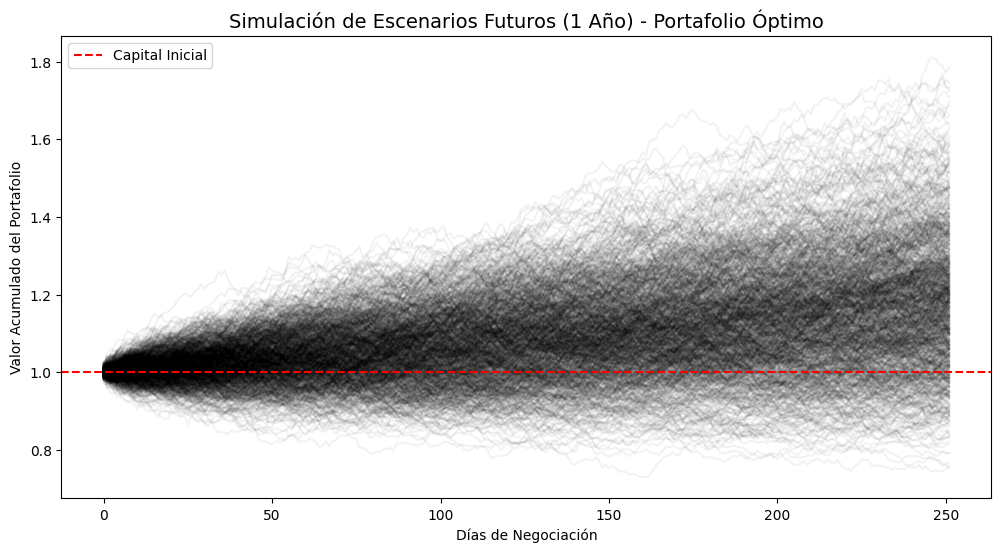

In [11]:
# --- VISUALIZACIÓN DE ESCENARIOS ---
plt.figure(figsize=(12, 6))
plt.plot(port_sims, color='black', alpha=0.05) # "Spaghetti plot"
plt.axhline(1.0, color='red', linestyle='--', label='Capital Inicial')
plt.title('Simulación de Escenarios Futuros (1 Año) - Portafolio Óptimo', fontsize=14)
plt.xlabel('Días de Negociación')
plt.ylabel('Valor Acumulado del Portafolio')
plt.legend()
plt.show()



In [12]:
# --- MÉTRICAS FINALES DE RIESGO ---
final_yields = port_sims[-1, :] - 1
var_95 = np.percentile(final_yields, 5)
cvar_95 = final_yields[final_yields <= var_95].mean()

print(f"--- REPORTE EJECUTIVO DE RIESGO ---")
print(f"Retorno Esperado (Escenario Promedio): {final_yields.mean():.2%}")
print(f"VaR (95% confianza): {var_95:.2%}")
print(f"CVaR (Pérdida en escenarios de crisis): {cvar_95:.2%}")

--- REPORTE EJECUTIVO DE RIESGO ---
Retorno Esperado (Escenario Promedio): 17.90%
VaR (95% confianza): -8.35%
CVaR (Pérdida en escenarios de crisis): -12.97%


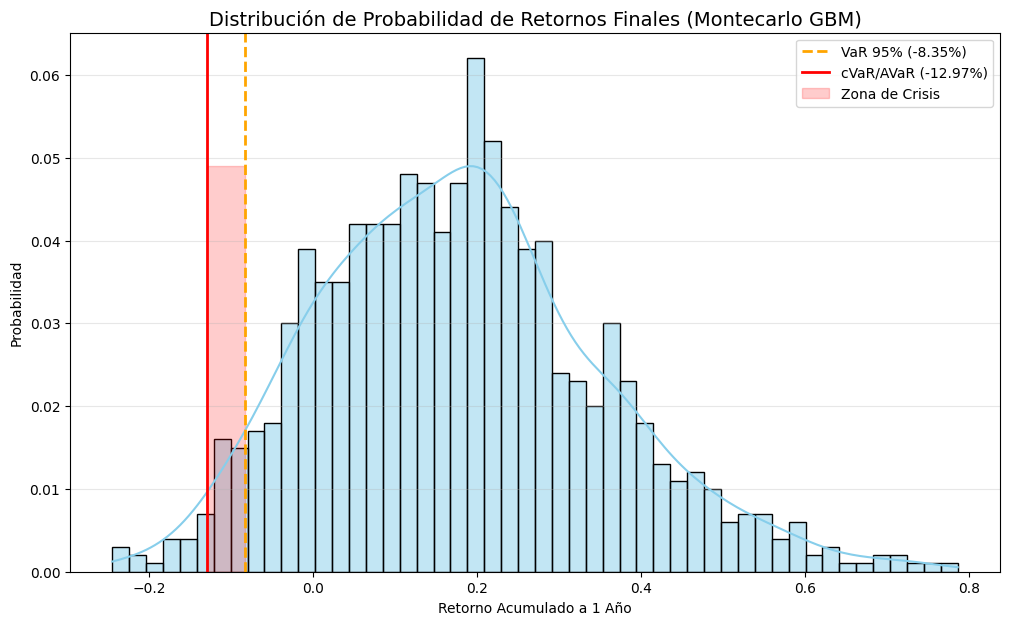

In [13]:
# REPRESENTACIÓN GRÁFICA DEL RIESGO (VaR Y cVaR)

plt.figure(figsize=(12, 7))
# Histograma de retornos finales de la simulación
sns.histplot(final_yields, kde=True, color='skyblue', stat="probability", bins=50)

# Línea del VaR
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95% ({var_95:.2%})')

# Sombreado del área del CVaR (Pérdida en la cola)
plt.axvline(cvar_95, color='red', linestyle='-', linewidth=2, label=f'cVaR/AVaR ({cvar_95:.2%})')
plt.fill_betweenx(np.arange(0, 0.05, 0.001), cvar_95, var_95, color='red', alpha=0.2, label='Zona de Crisis')

plt.title('Distribución de Probabilidad de Retornos Finales (Montecarlo GBM)', fontsize=14)
plt.xlabel('Retorno Acumulado a 1 Año')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [16]:
# SET DE DATOS A POWER BI / EXCEL: ESTRUCTURA DE TABLAS DIMENSIONALES Y FACTS PARA ANÁLISIS POSTERIOR

# 1. Dim_Activos
dim_activos = pd.DataFrame({
    'Ticker': tickers,
    'Nombre': ['Ecopetrol ADR', 'Bancolombia ADR', 'Nasdaq 100', 'Gold Shares', 'Total Bond Market'],
    'Clase': ['Equity', 'Equity', 'Equity', 'Commodity', 'Fixed Income']
})

# 2. Fact_Precios (Series históricas)
fact_precios = data.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Precio')
# Añadir retornos logarítmicos
fact_precios['Log_Return'] = log_returns.melt()['value']

# 3. Fact_Simulaciones (Nube de puntos de la Frontera Eficiente)
fact_simulaciones = pd.DataFrame({
    'Retorno': ret_arr,
    'Volatilidad': vol_arr,
    'Sharpe_Ratio': sharpe_arr
})

# 4. Fact_Risk_Metrics (Métricas finales)
fact_risk_metrics = pd.DataFrame({
    'Metrica': ['Retorno Esperado', 'VaR 95%', 'CVaR 95%'],
    'Valor': [final_yields.mean(), var_95, cvar_95]
})

# EXPORTACIÓN CON FORMATO: Separador ';' y decimal ','
config_export = {'sep': ';', 'decimal': ',', 'index': False, 'encoding': 'utf-16'}

dim_activos.to_csv('Dim_Activos.csv', **config_export)
fact_precios.to_csv('Fact_Precios.csv', **config_export)
fact_simulaciones.to_csv('Fact_Simulaciones.csv', **config_export)
fact_risk_metrics.to_csv('Fact_Risk_Metrics.csv', **config_export)

print("Archivos exportados exitosamente para Excel/Power BI.")

Archivos exportados exitosamente para Excel/Power BI.


In [7]:


# 1. Asegurar parámetros base (Usa tus variables de retorno logarítmico)
mu = log_returns.mean()
cov_matrix = log_returns.cov()

# AJUSTE TÉCNICO: Añadimos una pequeña constante a la diagonal (jitter) 
# para asegurar la convergencia numérica si la matriz es casi singular.
cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-8

pesos_optimos = np.array([0.0250, 0.0083, 0.0639, 0.5491, 0.3537]) 
n_simulaciones = 10000
dias_proyeccion = 252

# 2. Simulación usando una alternativa más estable: Cholesky Decomposition
try:
    # Intentamos la forma estándar con un chequeo de estabilidad
    L = np.linalg.cholesky(cov_matrix)
    port_ret_sim = np.zeros((dias_proyeccion, n_simulaciones))
    
    for i in range(dias_proyeccion):
        # Generamos ruido normal y lo proyectamos con Cholesky y la Media
        Z = np.random.standard_normal((n_simulaciones, len(mu)))
        daily_returns = mu.values + np.dot(Z, L.T)
        # Aplicamos pesos del portafolio
        port_ret_sim[i, :] = np.dot(daily_returns, pesos_optimos)

except np.linalg.LinAlgError:
    # Si Cholesky falla, usamos un método de emergencia (check_valid='ignore')
    print("Usando método de emergencia para matriz no definida positiva...")
    port_ret_sim = np.zeros((dias_proyeccion, n_simulaciones))
    for i in range(n_simulaciones):
        rand_ret = np.random.multivariate_normal(mu, cov_matrix, dias_proyeccion, check_valid='ignore')
        port_ret_sim[:, i] = np.dot(rand_ret, pesos_optimos)

# 3. Conversión a Retorno Acumulado
port_acum_sim = np.exp(np.cumsum(port_ret_sim, axis=0)) - 1

# 4. EXPORTACIÓN PARA PÁGINA 3
proyecciones_gbm = pd.DataFrame({
    'Dia': np.arange(1, dias_proyeccion + 1),
    'P5': np.percentile(port_acum_sim, 5, axis=1),
    'P50': np.percentile(port_acum_sim, 50, axis=1),
    'P95': np.percentile(port_acum_sim, 95, axis=1)
})
proyecciones_gbm.to_csv('Proyecciones_Trayectorias.csv', index=False)

distribucion_riesgo = pd.DataFrame({
    'Retorno_Final': port_acum_sim[-1, :]
})
distribucion_riesgo.to_csv('Distribucion_Riesgo.csv', index=False)

print("Archivos generados con éxito tras corregir error de convergencia.")

Archivos generados con éxito tras corregir error de convergencia.


In [3]:
import pandas as pd
import numpy as np

# 1. Preparación de retornos limpia
# Usamos 'data' que es el DataFrame de precios descargado de Yahoo Finance
log_returns_clean = np.log(data / data.shift(1)).dropna()
mu = log_returns_clean.mean()
cov_matrix = log_returns_clean.cov()

# 2. Configuración de parámetros (Declaración explícita de pesos)
# Usamos los pesos exactos de tu portafolio óptimo (Página 2)
pesos_optimos = np.array([0.0250, 0.0083, 0.0639, 0.5491, 0.3537]) 
n_simulaciones = 10000
dias_proyeccion = 252

# 3. Simulación Monte Carlo (GBM) estable
# Añadimos jitter para evitar el error de SVD/Cholesky
L = np.linalg.cholesky(cov_matrix + np.eye(len(mu)) * 1e-8)
port_ret_sim = np.zeros((dias_proyeccion, n_simulaciones))

for i in range(dias_proyeccion):
    Z = np.random.standard_normal((n_simulaciones, len(mu)))
    daily_returns = mu.values + np.dot(Z, L.T)
    port_ret_sim[i, :] = np.dot(daily_returns, pesos_optimos)

# 4. Cálculo de Retorno Acumulado y limpieza final
port_acum_sim = np.exp(np.cumsum(port_ret_sim, axis=0)) - 1
port_acum_sim = np.nan_to_num(port_acum_sim) # Seguridad contra NaNs

# 5. Generación de DataFrames para Power BI
proyecciones_gbm = pd.DataFrame({
    'Dia': np.arange(1, dias_proyeccion + 1),
    'P5': np.percentile(port_acum_sim, 5, axis=1),
    'P50': np.percentile(port_acum_sim, 50, axis=1),
    'P95': np.percentile(port_acum_sim, 95, axis=1)
})

distribucion_riesgo = pd.DataFrame({
    'Retorno_Final': port_acum_sim[-1, :]
})

# Verificación de salida
print("Primeras filas de la proyección:")
print(proyecciones_gbm.head())

# Guardar archivos
proyecciones_gbm.to_csv('Proyecciones_Trayectorias.csv', index=False)
distribucion_riesgo.to_csv('Distribucion_Riesgo.csv', index=False)

print("\nArchivos exportados exitosamente.")

Primeras filas de la proyección:
   Dia        P5       P50       P95
0    1 -0.014348  0.000643  0.015694
1    2 -0.020061  0.001281  0.023154
2    3 -0.023861  0.001945  0.029135
3    4 -0.027130  0.002497  0.033436
4    5 -0.029894  0.003287  0.036964

Archivos exportados exitosamente.
